# Práctica 3: Opciones europeas y americanas

## Ejercicios

1) Considera una estrategia Butterfly-Spread. Construye el mismo pay-off pero con opciones Put. Dibuja el pay-off obtenido para $K_{1}=10$, $K_{2}=20$, $K_{3}=30$.

In [ ]:
# Ejercicio 1)
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
# definimos los parámetros
K = np.array([10,20,30])

Construimos la estrategia utilizando opciones de venta, cuyos pay-offs vienen dados por:
$$P_{T}^{(i)} = \max(K_i-S_T,0)\quad i=1,2,3$$
La idea es construirla "de derecha a izquierda". Comenzamos comprando una opción $P^{(3)}$, vendemos dos opciones $P^{(2)}$ y compramos una $P^{(1)}$. Ahora comprobamos que la cartera formada:
$$ \Pi_T = P^{(1)}_T -2P^{(2)}_T + P^{(3)}_T $$
cumple lo que queremos.

In [ ]:
def Pi(S):
    return np.maximum(K[0]-S,0) -2*np.maximum(K[1]-S,0) + np.maximum(K[2]-S,0)

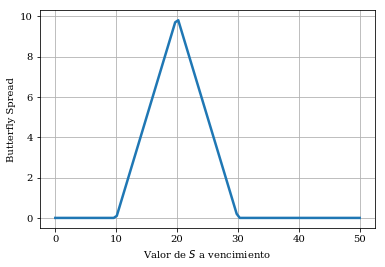

In [ ]:
# Salida gráfica
ST = np.linspace(0, 50, 100)  # valores del subyacente
PiT = Pi(ST)  # valores de la cartera
plt.figure()
plt.plot(ST, PiT, lw=2.5)  # gráfica de valores a vencimiento
plt.xlabel('Valor de $S$ a vencimiento')
plt.ylabel('Butterfly Spread')
plt.grid(True)

2) Construye una estrategia con pay-off que gane cuando $S_{T}<K_{1}$ y cuando $S_{T}>K_{3}$ y que no pierda cuando $K_{1}\leq S_{T}\leq K_{3}$ usando los valores de $K_{1}$, $K_{2}$ y $K_{3}$ del ejercicio 1). Dibuja el perfil de pagos de la estrategia en función de $S_{T}$.

**Respuesta:** una estrategia posible es comprar una opción de **venta** con strike $K_1$ y una opción de **compra** con strike $K_3$. Veamos los perfiles de pagos.

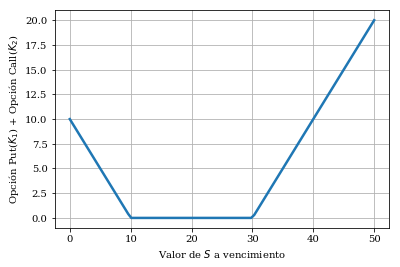

In [ ]:
def Pi2(S):
    return np.maximum(K[0]-S,0) + np.maximum(S - K[2],0)

PiT = Pi2(ST)  # valores de la cartera
plt.figure()
plt.plot(ST, PiT, lw=2.5)  # gráfica de valores a vencimiento
plt.xlabel('Valor de $S$ a vencimiento')
plt.ylabel('Opción Put($K_1$) + Opción Call($K_2$)')
plt.grid(True)

3) Construye una oportunidad de arbitraje en el caso de que la opción Call europea sea más cara que la correspondiente americana.

**Respuesta** Estudia el pay-off de una cartera $\Pi$ construida así:
$$\Pi_t=(C^E_0 - C^A_0)B_t + C^A_t - C^E_t$$
Como estamos endeudados en la opción europea, podemos elegir esperar hasta tiempo $T$ para ejercer la americana y cubrir las deudas. Verifica que se ganaría en todos los escenarios.

# Práctica
Considera un contrato que pague en función de un parámetro $h>0$:

$$
\mbox{pay-off}\left(h\right)=\begin{cases}
1 & S_{T}\geq K+h\\
\frac{S_{T}-K}{h} & K\leq S_{T} < K+h\\
0 & S_{T}<K
\end{cases}
$$

Dibuja el pay-off para K=100 y distintos valores de h. Construye una cartera de opciones que replique este pay-off e investiga estas cuestiones:

1. ¿A qué perfil converge el pay-off para $h\to0$? Comprueba, gráficamente, que el pay-off de la cartera coincide con el del contrato.

2. Asumiendo conocidos los precios de las opciones de compra con strike $\in\left(K-\varepsilon,K+\varepsilon\right)$ con $\varepsilon>0$ para un vencimiento fijo $T$, escribe el precio del instrumento para $h\simeq0$ en función de los precios de las opciones.